In [ ]:
import numpy as np
import scipy.sparse as scisparse
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from skfem import *
from skfem.helpers import dot, grad
from tqdm import tqdm
import time

# Try importing pypardiso for speed, fallback to scipy if missing
try:
    from pypardiso import spsolve
    USING_PARDISO = True
    print("Using pypardiso for fast solving.")
except ImportError:
    from scipy.sparse.linalg import spsolve
    USING_PARDISO = False
    print("pypardiso not found. Using scipy.sparse.linalg.spsolve (slower).")

# ==========================================
# 1. Configuration & Parameters
# ==========================================
L = 32.0 * np.pi 
N = 128             # Spatial Resolution (128x128)
DT = 0.25           # Time step
NU = 1.0            # Viscosity
GAMMA = 0.3
VELOCITY = (0.5,0.5)
ALPHA = 1e-9        # Regularisation for augmented constraint block
T_STEPS = 600       # Number of time steps
NEWTON_MAX = 10     # Max nonlinear iterations
NEWTON_TOL = 1e-5   # Nonlinear convergence tolerance

# ==========================================
# 2. FEM Setup (Mixed Formulation)
# ==========================================
# Mesh: Structured Grid for Periodic BC mapping
mesh = MeshTri.init_tensor(
    np.linspace(0, L, N+1),
    np.linspace(0, L, N+1)
)
element = ElementTriP1()
basis = Basis(mesh, element)

# Boundary DOFs identification
dofs_left   = basis.get_dofs(lambda x: np.isclose(x[0], 0.0))
dofs_right  = basis.get_dofs(lambda x: np.isclose(x[0], L))
dofs_bottom = basis.get_dofs(lambda x: np.isclose(x[1], 0.0))
dofs_top    = basis.get_dofs(lambda x: np.isclose(x[1], L))

# ==========================================
# 3. Forms & Matrices
# ==========================================

# -- Bilinear Forms (Constant Matrices) --
@BilinearForm
def M_mat(u, v, w):
    return u * v

@BilinearForm
def A_mat(u, v, w):
    return dot(u.grad, v.grad)

# -- Nonlinear Terms (Assembled every Newton Step) --
@LinearForm
def F_nonlinear(v, w):
    # Vector: 0.5 * |grad(u)|^2 * v
    # damping = GAMMA * w.u_1 * v
    advection = (VELOCITY[0] * w.u_1.grad[0] + VELOCITY[1] * w.u_1.grad[1]) * v
    return 0.5 * dot(w.u_1.grad, w.u_1.grad) * v + DT * advection

@BilinearForm
def J_nonlinear(u, v, w):
    # Jacobian: dot(grad(u_k), grad(du)) * v
    return dot(w.u_k.grad, u.grad) * v

# ==========================================
# 4. Constraint Builder
# ==========================================
def build_periodic_constraints(basis):
    """Builds the constraint matrix C for periodic BCs."""
    idx_l = dofs_left.flatten()
    idx_r = dofs_right.flatten()
    idx_b = dofs_bottom.flatten()
    idx_t = dofs_top.flatten()
    
    # Sort by coordinate to ensure nodes align
    coords = basis.doflocs
    y_l = coords[1, idx_l]; p_l = np.argsort(y_l); idx_l = idx_l[p_l]
    y_r = coords[1, idx_r]; p_r = np.argsort(y_r); idx_r = idx_r[p_r]
    x_b = coords[0, idx_b]; p_b = np.argsort(x_b); idx_b = idx_b[p_b]
    x_t = coords[0, idx_t]; p_t = np.argsort(x_t); idx_t = idx_t[p_t]
    
    n_dofs = basis.N
    row, col, val = [], [], []
    row_idx = 0
    
    # Helper to add constraints
    def add_cons(idx1, idx2, offset):
        nonlocal row_idx
        for i, j in zip(idx1, idx2):
            # u constraint
            row.extend([row_idx, row_idx])
            col.extend([i + offset, j + offset])
            val.extend([-1, 1])
            row_idx += 1
            
    # Apply to u (offset 0) and w (offset N)
    add_cons(idx_l, idx_r, 0) # u Left-Right
    add_cons(idx_b, idx_t, 0) # u Bottom-Top
    add_cons(idx_l, idx_r, n_dofs) # w Left-Right
    add_cons(idx_b, idx_t, n_dofs) # w Bottom-Top
        
    return scisparse.coo_matrix((val, (row, col)), shape=(row_idx, 2*n_dofs))

# ==========================================
# 5. Pre-Assembly (The Optimization)
# ==========================================
print("Assembling constant matrices...")
M = M_mat.assemble(basis).tocsc()
A = A_mat.assemble(basis).tocsc()
C_matrix = build_periodic_constraints(basis)

C_csc = C_matrix.tocsc()
CT_csc = C_matrix.T.tocsc()

# Augmented System Constants
n_cons = C_matrix.shape[0]
n_dofs = 2 * basis.N
Reg_block = scisparse.identity(n_cons, format='csc') * -ALPHA
Zero_N = scisparse.csc_matrix((basis.N, basis.N)) # Helper for bmat

# Constant parts of the Jacobian
# Derived from Implicit Euler of Mixed Form
J11_const = (1/DT) * M 
J12_const = -NU * A + M
J21_const = A
J22_const = M

J_const = scisparse.bmat([
    [J11_const, J12_const],
    [J21_const, J22_const]
], format='csc')

# ==========================================
# 6. Initial Conditions
# ==========================================
np.random.seed(42)
coords = basis.doflocs
x_c, y_c = coords[0], coords[1]

# --- Validation IC: "The Egg Carton" (Mode 11) ---
# This creates a perfect lattice that eventually breaks into chaos
n_mode = 11
u_init = 0.5 * (np.cos(n_mode * x_c * 2*np.pi/L) + np.cos(n_mode * y_c * 2*np.pi/L))
u_init += 0.01 * np.random.randn(basis.N) # Tiny noise to seed the break

u_prev = u_init
w_prev = np.zeros_like(u_prev)
state = np.concatenate([u_prev, w_prev])

# ==========================================
# 7. Simulation Loop
# ==========================================
solutions = []
roughnesses = []

print(f"Starting simulation for {T_STEPS} steps...")
start_time = time.time()

for step in tqdm(range(T_STEPS)):
    guess = state.copy()
    u_prev = state[:basis.N]
    
    # Newton Loop
    for newton_iter in range(NEWTON_MAX):
        u_k = guess[:basis.N]
        w_k = guess[basis.N:]
        
        # 1. Residual Calculation (Vector Algebra)
        # Linear parts
        r1_lin = (1/DT) * M @ (u_k - u_prev) + (-NU * A + M) @ w_k
        r2_lin = M @ w_k + A @ u_k
        # Nonlinear part
        r1_nonlin = F_nonlinear.assemble(basis, u_1=basis.interpolate(u_k))
        R = np.concatenate([r1_lin + r1_nonlin, r2_lin])
        
        # 2. Jacobian Calculation (Sparse Update)
        J_nl_block = J_nonlinear.assemble(basis, u_k=basis.interpolate(u_k))
        
        # Inject Nonlinear Jacobian into Top-Left Block
        J_nl_expanded = scisparse.bmat([
            [J_nl_block, None],
            [None,       Zero_N]
        ], format='csc')
        J_total = J_const + J_nl_expanded
        
        # 3. Augmented System Solve
        g = C_csc @ guess
        
        KKT = scisparse.bmat([
            [J_total, CT_csc],
            [C_csc,   Reg_block]
        ], format='csc')
        
        RHS = np.concatenate([-R, -g])
        
        delta_aug = spsolve(KKT, RHS)
        delta = delta_aug[:n_dofs]
        
        guess += delta
        if np.linalg.norm(delta) < NEWTON_TOL:
            break
            
    state = guess
    
    # Post-processing
    u_curr = state[:basis.N]
    u_fluc = u_curr - np.mean(u_curr)
    roughnesses.append(np.sqrt(np.mean(u_fluc**2)))
    solutions.append(u_curr.copy())

print(f"Simulation finished in {time.time()-start_time:.2f}s")

Using pypardiso for fast solving.
Assembling constant matrices...
Starting simulation for 600 steps...


100%|██████████| 600/600 [13:07<00:00,  1.31s/it]

Simulation finished in 787.64s


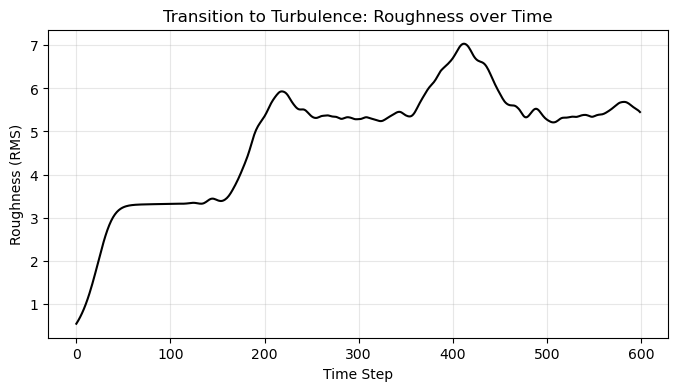

Generating animation (600 frames)...
Saved to ks_chaos.mp4


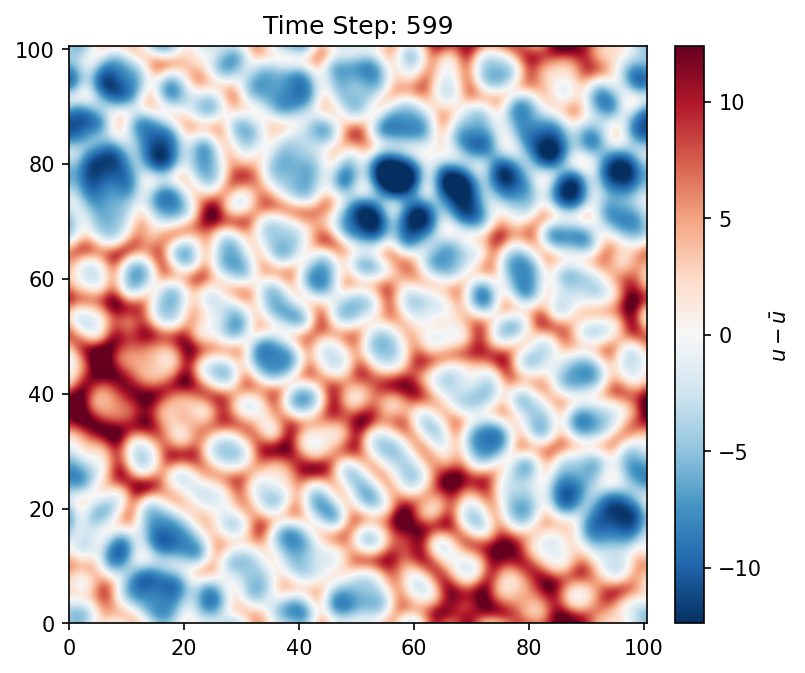

In [62]:
# ==========================================
# 8. Visualization Functions
# ==========================================
def save_animation_hd(solutions, filename="ks_simulation_hd.mp4", shape=(N+1, N+1), fps=60):
    data_raw = [s.reshape(shape) - np.mean(s) for s in solutions]
    data = np.array(data_raw)
    
    # Smart contrast limits
    vmin = np.percentile(data, 1)
    vmax = np.percentile(data, 99)
    limit = max(abs(vmin), abs(vmax))
    
    fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
    im = ax.imshow(data[0], origin='lower', cmap='RdBu_r', 
                   interpolation='bicubic', vmin=-limit, vmax=limit,
                   extent=[0, L, 0, L])
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("$u - \\bar{u}$")
    title = ax.set_title(f"Time Step: 0")

    def update(frame):
        im.set_data(data[frame])
        title.set_text(f"Time Step: {frame}")
        return im, title

    print(f"Generating animation ({len(data)} frames)...")
    anim = animation.FuncAnimation(fig, update, frames=len(data), blit=True)
    
    if filename.endswith('.mp4'):
        # Requires ffmpeg installed
        anim.save(filename, writer='ffmpeg', fps=fps, bitrate=3000)
    else:
        anim.save(filename, writer='pillow', fps=fps)
    print(f"Saved to {filename}")

def plot_roughness(roughnesses):
    plt.figure(figsize=(8, 4))
    plt.plot(roughnesses, 'k-', lw=1.5)
    plt.title("Transition to Turbulence: Roughness over Time")
    plt.xlabel("Time Step")
    plt.ylabel("Roughness (RMS)")
    plt.grid(True, alpha=0.3)
    plt.show()

# Run Visualization
plot_roughness(roughnesses)
save_animation_hd(solutions, filename="ks_chaos.mp4") # Uncomment to save video

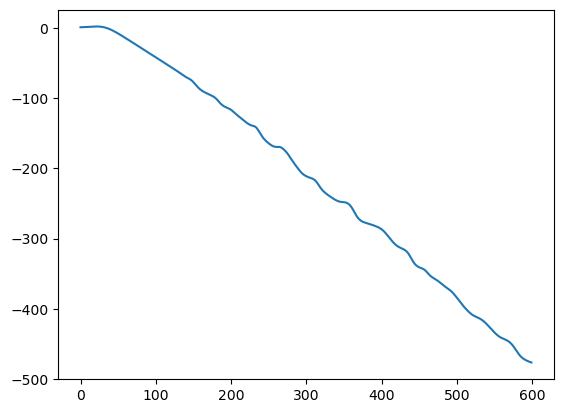

In [55]:
plt.plot(np.asarray(solutions)[:,0])

In [ ]:
import numpy as np
from skfem import *
from skfem.helpers import dot, grad
import scipy.sparse as scisparse
from tqdm import tqdm
import matplotlib.pyplot as plt

# Updated Parameters
L = 32.0 * np.pi 
N = 128             # INCREASED from 64 to resolve the cellular structures
DT = 0.25           # Can actually increase DT slightly if spatial res is good
NU = 1.0            # Viscosity (Tune this: 1.0 is standard for L=32pi)
ALPHA = 1e-9      # Regularisation for augmented block

# 1. Mesh and Basis (2D)
# We use init_tensor to ensure a structured grid, making PBCs easier to map
mesh = MeshTri.init_tensor(
    np.linspace(0, L, N+1),
    np.linspace(0, L, N+1)
)
element = ElementTriP1()
basis = Basis(mesh, element)

# Helper to identify boundary DOFs
# Rounding is important for float comparisons
dofs_left   = basis.get_dofs(lambda x: np.isclose(x[0], 0.0))
dofs_right  = basis.get_dofs(lambda x: np.isclose(x[0], L))
dofs_bottom = basis.get_dofs(lambda x: np.isclose(x[1], 0.0))
dofs_top    = basis.get_dofs(lambda x: np.isclose(x[1], L))

# 2. Forms
@LinearForm
def F_1(v, w):
    # w.u_1: current u estimate
    # w.u_0: previous timestep u
    # w.w_1: current w estimate (laplacian)
    
    # Nonlinearity: 0.5 * |grad(u)|^2
    # In skfem, w.u_1.grad is a vector. dot(a,b) handles the sum of squares.
    nonlin = 0.5 * dot(w.u_1.grad, w.u_1.grad)
    
    return (
        (w.u_1 - w.u_0) * v 
        - DT * NU * dot(w.w_1.grad, v.grad)  # Note signs from Integration by Parts
        + DT * w.w_1 * v 
        + DT * nonlin * v
    )

@LinearForm
def F_2(v, w):
    # w - Laplacian(u) = 0
    # Int(w*v) + Int(grad(u).grad(v)) = 0
    return (
        w.w_1 * v 
        + dot(w.u_1.grad, v.grad)
    )

# --- Jacobian Blocks ---

@BilinearForm
def M_mat(u, v, w):
    return u * v

@BilinearForm
def A_mat(u, v, w):
    return dot(u.grad, v.grad) # Laplacian-like operator

@BilinearForm
def J_nonlinear(u, v, w):
    # Linearization of (grad(u_k) . grad(du)) * v
    # u here is the trial function (du in Newton)
    # w.u_k is the current guess
    return dot(w.u_k.grad, u.grad) * v

def build_periodic_constraints(basis):
    # Map spatial coordinates to find matching pairs
    # This is a bit manual but robust
    
    # Helper to get indices from DofObjects
    idx_l = dofs_left.flatten()
    idx_r = dofs_right.flatten()
    idx_b = dofs_bottom.flatten()
    idx_t = dofs_top.flatten()
    
    # Because mesh is structured, we can assume sorting by y works for L/R pair
    # and sorting by x works for B/T pair.
    
    # Get coordinates
    coords = basis.doflocs
    
    # Sort L/R by y-coordinate
    y_l = coords[1, idx_l]; p_l = np.argsort(y_l); idx_l = idx_l[p_l]
    y_r = coords[1, idx_r]; p_r = np.argsort(y_r); idx_r = idx_r[p_r]
    
    # Sort B/T by x-coordinate
    x_b = coords[0, idx_b]; p_b = np.argsort(x_b); idx_b = idx_b[p_b]
    x_t = coords[0, idx_t]; p_t = np.argsort(x_t); idx_t = idx_t[p_t]
    
    # Build C matrix
    # Constraint: u_R - u_L = 0  =>  1*u_R + (-1)*u_L = 0
    # Constraint: w_R - w_L = 0
    
    # Number of constraints
    n_cons_lr = len(idx_l)
    n_cons_bt = len(idx_b)
    n_cons = 2 * (n_cons_lr + n_cons_bt) # *2 for u and w variables
    
    n_dofs = basis.N
    
    row = []
    col = []
    val = []
    
    row_idx = 0
    
    # U Constraints (Left-Right)
    for l, r in zip(idx_l, idx_r):
        row.extend([row_idx, row_idx])
        col.extend([l, r])
        val.extend([-1, 1])
        row_idx += 1

    # U Constraints (Bottom-Top)
    for b, t in zip(idx_b, idx_t):
        row.extend([row_idx, row_idx])
        col.extend([b, t])
        val.extend([-1, 1])
        row_idx += 1
        
    # W Constraints (Left-Right) - shift cols by n_dofs
    for l, r in zip(idx_l, idx_r):
        row.extend([row_idx, row_idx])
        col.extend([l + n_dofs, r + n_dofs])
        val.extend([-1, 1])
        row_idx += 1

    # W Constraints (Bottom-Top)
    for b, t in zip(idx_b, idx_t):
        row.extend([row_idx, row_idx])
        col.extend([b + n_dofs, t + n_dofs])
        val.extend([-1, 1])
        row_idx += 1
        
    C = scisparse.coo_matrix((val, (row, col)), shape=(row_idx, 2*n_dofs))
    return C

print("Assembling constant matrices...")
M = M_mat.assemble(basis)
A = A_mat.assemble(basis)
C_matrix = build_periodic_constraints(basis)

M = M.tocsc()
A = A.tocsc()
C_csc = C_matrix.tocsc()
CT_csc = C_matrix.T.tocsc()

n_cons = C_matrix.shape[0]
n_dofs = 2 * basis.N
Zero_block = scisparse.csc_matrix((n_cons, n_cons))
Reg_block = scisparse.identity(n_cons, format='csc') * -ALPHA

J11_const = (1/DT) * M 
J12_const = -NU * A + M
J21_const = A
J22_const = M

J_const = scisparse.bmat([
    [J11_const, J12_const],
    [J21_const, J22_const]
], format='csc')

@LinearForm
def F_nonlinear(v, w):
    # Only the 0.5 * |grad(u)|^2 * v term
    return 0.5 * dot(w.u_1.grad, w.u_1.grad) * v

@BilinearForm
def J_nonlinear(u, v, w):
    # Linearization: dot(grad(u_k), grad(du)) * v
    return dot(w.u_k.grad, u.grad) * v

# 3. Assembly Functions
def compute_residual(u_k, w_k, u_prev, w_prev):
    refs = {
        'u_1': basis.interpolate(u_k),
        'u_0': basis.interpolate(u_prev),
        'w_1': basis.interpolate(w_k),
    }
    
    r1 = F_1.assemble(basis, **refs)
    r2 = F_2.assemble(basis, **refs)
    return np.concatenate([r1, r2])

def compute_jacobian(u_k):
    # Standard Matrices (Constant)
    M = M_mat.assemble(basis)
    A = A_mat.assemble(basis)
    
    # Nonlinear Part (Dependent on current guess u_k)
    J_nl = J_nonlinear.assemble(basis, u_k=basis.interpolate(u_k))
    
    # Block Construction
    # Eq 1: (1/dt)du + nu*Lap(dw) + dw + d(Nonlinear)
    #       (1/dt)M  +      0     + M  + J_nl (acting on u)
    # Wait: In mixed form (Eq 1), w is a variable. 
    # Term: -nu * lap(w) -> +nu * A (integrated by parts)
    # Term: +w -> +M
    
    # dF1/du = (1/dt)M + J_nl
    # dF1/dw = -NU * A + M  (Check signs carefully against F_1 definition)
    # Note: In F_1 linear form I wrote: - DT * NU * dot(grad(w), grad(v))
    # So Jacobian w.r.t w is: - DT * NU * A
    # And term + DT * w * v  -> + DT * M
    
    j11 = M + DT * J_nl
    j12 = -DT * NU * A + DT * M
    
    # Eq 2: w - lap(u) = 0
    # dF2/du = lap(u) -> A
    # dF2/dw = M
    j21 = A
    j22 = M
    
    return scisparse.bmat([[j11, j12], [j21, j22]], format='lil')

# 4. Construct Constraint Matrix C (Periodic)
# We need to map left DOFs to right DOFs, and Bottom to Top.
# We do this once.


# 5. Simulation Loop
# NEW Initial Condition: Superposition of random cosine waves
# This encourages the formation of physics-compliant structures early on
np.random.seed(42)
coords = basis.doflocs
x_c, y_c = coords[0], coords[1]
u_init = np.zeros(basis.N)

# # Add 5 random modes
# for _ in range(5):
#     kx = np.random.randint(1, 6)
#     ky = np.random.randint(1, 6)
#     phase = np.random.rand() * 2 * np.pi
#     u_init += 0.5 * np.cos(kx * x_c * 2*np.pi/L + phase) * np.cos(ky * y_c * 2*np.pi/L)

# # Add small noise to break symmetries
# u_init += 0.05 * np.random.randn(basis.N)

n_mode = 11
u_init = 0.5 * (np.cos(n_mode * x_c * 2*np.pi/L) + np.cos(n_mode * y_c * 2*np.pi/L))

# Add TINY noise to eventually trigger the transition to chaos
u_init += 0.01 * np.random.randn(basis.N)

u_prev = u_init
w_prev = np.zeros_like(u_prev) # Initial w is technically lap(u), but 0 is safe for Newton
state = np.concatenate([u_prev, w_prev])

Zero_N = scisparse.csc_matrix((basis.N, basis.N))

# Re-enable solution storage
solutions = []
roughnesses = []

# Pre-allocate sparse constraint blocks to save time
C_csc = C_matrix.tocsc()
CT_csc = C_matrix.T.tocsc()
Zero_block = scisparse.csc_matrix((C_matrix.shape[0], C_matrix.shape[0]))
# Optional: regularisation for C matrix diagonal
Reg_block = scisparse.identity(C_matrix.shape[0], format='csc') * -ALPHA

# --- 3. THE FAST LOOP ---
import time
from pypardiso import spsolve # Uncomment if installed, otherwise use scisparse.linalg.spsolve

for step in tqdm(range(600)):
    t0 = time.time()
    
    guess = state.copy()
    u_prev = state[:basis.N]
    
    # Newton Loop
    for newton_iter in range(10):
        u_k = guess[:basis.N]
        w_k = guess[basis.N:]
        
        # --- A. Fast Residual Calculation ---
        r1_lin = (1/DT) * M @ (u_k - u_prev) + (-NU * A + M) @ w_k
        r2_lin = M @ w_k + A @ u_k
        
        # Nonlinear residual
        r1_nonlin = F_nonlinear.assemble(basis, u_1=basis.interpolate(u_k))
        
        R = np.concatenate([r1_lin + r1_nonlin, r2_lin])
        
        # --- B. Fast Jacobian Calculation ---
        J_nl_block = J_nonlinear.assemble(basis, u_k=basis.interpolate(u_k))
        
        # FIX: Explicitly define the bottom-right as Zero_N so bmat sees (2N x 2N)
        J_nl_expanded = scisparse.bmat([
            [J_nl_block, None],
            [None,       Zero_N]
        ], format='csc')
        
        # Simple addition of sparse matrices (fast)
        J_total = J_const + J_nl_expanded
        
        # --- C. Augmented Solve ---
        g = C_csc @ guess
        
        KKT = scisparse.bmat([
            [J_total, CT_csc],
            [C_csc,   Reg_block]
        ], format='csc')
        
        RHS = np.concatenate([-R, -g])
        
        # Solve
        # Use pypardiso if you have it, otherwise standard scipy
        try:
            from pypardiso import spsolve
            delta_aug = spsolve(KKT, RHS)
        except ImportError:
            delta_aug = scisparse.linalg.spsolve(KKT, RHS)
            
        delta = delta_aug[:n_dofs]
        
        guess += delta
        if np.linalg.norm(delta) < 1e-5:
            break
            
    state = guess

    u_fluctuation = u_k - np.mean(u_k)
    roughness = np.sqrt(np.mean(u_fluctuation**2))
    roughnesses.append(roughness)
    
    # Store solution periodically
    # if step % 2 == 0:
    solutions.append(state[:basis.N].copy())
        
    # print(f"Step {step} took {time.time()-t0:.4f}s")

# for step in tqdm(range(200)): # Run for 200 steps
    
#     # Prediction (Use previous state as guess)
#     guess = state.copy()
    
#     # Newton Loop
#     for newton_iter in range(10):
#         u_k = guess[:basis.N]
#         w_k = guess[basis.N:]
        
#         # 1. Residuals
#         R = compute_residual(u_k, w_k, u_prev, w_prev)
        
#         # 2. Jacobian
#         J = compute_jacobian(u_k)
        
#         # 3. Augmented System
#         # [ J   C.T ] [ dx ] = [ -R ]
#         # [ C    0  ] [ lam]   [ -g ]
        
#         # Calculate constraint violation g = C * guess
#         g = C_matrix @ guess # Should be 0 if satisfied
        
#         # Build KKT Matrix
#         KKT = scisparse.bmat([
#             [J, CT_csc],
#             [C_csc, Reg_block]
#         ], format='csc')
        
#         RHS = np.concatenate([-R, -g])
        
#         # Solve
#         delta_aug = scisparse.linalg.spsolve(KKT, RHS)
#         delta = delta_aug[:2*basis.N]
        
#         guess += delta
        
#         norm = np.linalg.norm(delta)
#         if norm < 1e-5:
#             break
            
#     state = guess
#     u_prev = state[:basis.N]
#     w_prev = state[basis.N:]
    
#     if step % 5 == 0:
#         solutions.append(u_prev.copy())

# # Plotting one frame
# # vt.plot_field(solutions[-1], basis) # Assuming you have a plotter

Assembling constant matrices...


 28%|██▊       | 660/2400 [09:26<24:53,  1.16it/s]


KeyboardInterrupt: 

In [ ]:
def save_animation_hd(solutions, filename="ks_simulation_hd.mp4", shape=(129, 129), fps=60):
    # 1. Process Data
    # Subtract mean per frame to remove drift
    data_raw = [s.reshape(shape) - np.mean(s) for s in solutions]
    data = np.array(data_raw)
    
    # 2. Smart Contrast Limits
    # Instead of absolute min/max, use percentiles to ignore outliers
    # This makes the "structure" much sharper to the eye
    vmin = np.percentile(data, 1)
    vmax = np.percentile(data, 99)
    # Make it symmetric around 0 for Red-Blue colormap
    limit = max(abs(vmin), abs(vmax))
    vmin, vmax = -limit, limit

    fig, ax = plt.subplots(figsize=(6, 5), dpi=200) # Increased DPI for sharpness
    
    # 3. Use imshow instead of pcolormesh
    # origin='lower' is crucial because FEM usually maps (0,0) to index 0
    im = ax.imshow(data[0], 
                   origin='lower', 
                   cmap='viridis',       # Diverging colormap (Red-White-Blue)
                   interpolation='nearest', # 'bicubic' is sharp but smooth. Try 'nearest' for pixels.
                   vmin=vmin, vmax=vmax,
                   extent=[0, 32*np.pi, 0, 32*np.pi]) # Set actual axis labels
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Fluctuation $u - \\bar{u}$")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    
    title = ax.set_title(f"Time Step: 0")

    def update(frame):
        im.set_data(data[frame])
        title.set_text(f"Time Step: {frame}")
        return im, title

    print(f"Generating HD animation ({len(data)} frames)...")
    anim = animation.FuncAnimation(fig, update, frames=len(data), blit=True)
    
    # High bitrate for MP4 to avoid compression artifacts
    if filename.endswith('.mp4'):
        anim.save(filename, writer='ffmpeg', fps=fps, dpi=200, bitrate=3000)
    else:
        anim.save(filename, writer='pillow', fps=fps)
        
    plt.close(fig)
    print(f"Saved to {filename}")

# Usage with your data:
save_animation_hd(solutions, shape=(129, 129))

Generating HD animation (660 frames)...
Saved to ks_simulation_hd.mp4


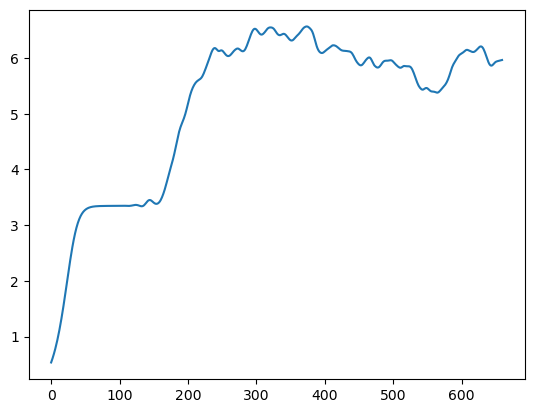

In [50]:
plt.plot(roughnesses)

In [22]:
np.asarray(solutions).shape

(9, 4225)